In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization

In [2]:
from google.colab import files

uploaded = files.upload()

Saving diabetes.csv to diabetes.csv


In [3]:
df = pd.read_csv("diabetes.csv")

df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [4]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [5]:
X = df.drop("Outcome", axis=1)
y = df["Outcome"]

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [7]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [8]:
model_without_bn = Sequential([
    Dense(64, activation='relu', input_shape=(8,)),
    Dropout(0.3),

    Dense(32, activation='relu'),
    Dropout(0.3),

    Dense(1, activation='sigmoid')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [9]:
model_without_bn.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [10]:
history_without_bn = model_without_bn.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=16,
    verbose=1
)

Epoch 1/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.6680 - loss: 0.6293 - val_accuracy: 0.7480 - val_loss: 0.5746
Epoch 2/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7271 - loss: 0.5695 - val_accuracy: 0.7561 - val_loss: 0.5236
Epoch 3/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7393 - loss: 0.5249 - val_accuracy: 0.7805 - val_loss: 0.4900
Epoch 4/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7495 - loss: 0.5063 - val_accuracy: 0.7886 - val_loss: 0.4671
Epoch 5/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7658 - loss: 0.4980 - val_accuracy: 0.7967 - val_loss: 0.4491
Epoch 6/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7800 - loss: 0.4873 - val_accuracy: 0.8130 - val_loss: 0.4394
Epoch 7/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7739 - loss: 0.4855 - val_accuracy: 0.7967 - val_loss: 0.4347
Epoch 8/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7699 - loss: 0.4784 - val_accuracy: 0.7967 - val_loss

In [11]:
y_pred = model_without_bn.predict(X_test)
y_pred = (y_pred > 0.5).astype(int)

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
Accuracy : 0.7337662337662337
Precision: 0.6326530612244898
Recall   : 0.5740740740740741
F1 Score : 0.6019417475728155


In [12]:
model_with_bn = Sequential([
    Dense(64, activation='relu', input_shape=(8,)),
    BatchNormalization(),
    Dropout(0.3),

    Dense(32, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),

    Dense(1, activation='sigmoid')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [13]:
model_with_bn.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [14]:
history_with_bn = model_with_bn.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=16,
    verbose=1
)

Epoch 1/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.6191 - loss: 0.7550 - val_accuracy: 0.7561 - val_loss: 0.6231
Epoch 2/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6334 - loss: 0.6929 - val_accuracy: 0.7724 - val_loss: 0.5957
Epoch 3/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6823 - loss: 0.6276 - val_accuracy: 0.7724 - val_loss: 0.5703
Epoch 4/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6904 - loss: 0.6090 - val_accuracy: 0.7886 - val_loss: 0.5382
Epoch 5/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7271 - loss: 0.5707 - val_accuracy: 0.8049 - val_loss: 0.5074
Epoch 6/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7210 - loss: 0.5655 - val_accuracy: 0.7967 - val_loss: 0.4785
Epoch 7/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7373 - loss: 0.5340 - val_accuracy: 0.7967 - val_loss: 0.4624
Epoch 8/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7251 - loss: 0.5522 - val_accuracy: 0.7967 - val_loss

In [15]:
y_pred_bn = model_with_bn.predict(X_test)
y_pred_bn = (y_pred_bn > 0.5).astype(int)

print("Accuracy :", accuracy_score(y_test, y_pred_bn))
print("Precision:", precision_score(y_test, y_pred_bn))
print("Recall   :", recall_score(y_test, y_pred_bn))
print("F1 Score :", f1_score(y_test, y_pred_bn))

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
Accuracy : 0.7662337662337663
Precision: 0.6666666666666666
Recall   : 0.6666666666666666
F1 Score : 0.6666666666666666


In [16]:
print("Without Batch Normalization")
print(classification_report(y_test, y_pred))

print("\nWith Batch Normalization")
print(classification_report(y_test, y_pred_bn))

Without Batch Normalization
              precision    recall  f1-score   support

           0       0.78      0.82      0.80       100
           1       0.63      0.57      0.60        54

    accuracy                           0.73       154
   macro avg       0.71      0.70      0.70       154
weighted avg       0.73      0.73      0.73       154


With Batch Normalization
              precision    recall  f1-score   support

           0       0.82      0.82      0.82       100
           1       0.67      0.67      0.67        54

    accuracy                           0.77       154
   macro avg       0.74      0.74      0.74       154
weighted avg       0.77      0.77      0.77       154



In [17]:
results = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1 Score"],
    "Without BatchNorm": [
        accuracy_score(y_test, y_pred),
        precision_score(y_test, y_pred),
        recall_score(y_test, y_pred),
        f1_score(y_test, y_pred)
    ],
    "With BatchNorm": [
        accuracy_score(y_test, y_pred_bn),
        precision_score(y_test, y_pred_bn),
        recall_score(y_test, y_pred_bn),
        f1_score(y_test, y_pred_bn)
    ]
})

results

,Metric,Without BatchNorm,With BatchNorm
0,Accuracy,0.733766,0.766234
1,Precision,0.632653,0.666667
2,Recall,0.574074,0.666667
3,F1 Score,0.601942,0.666667


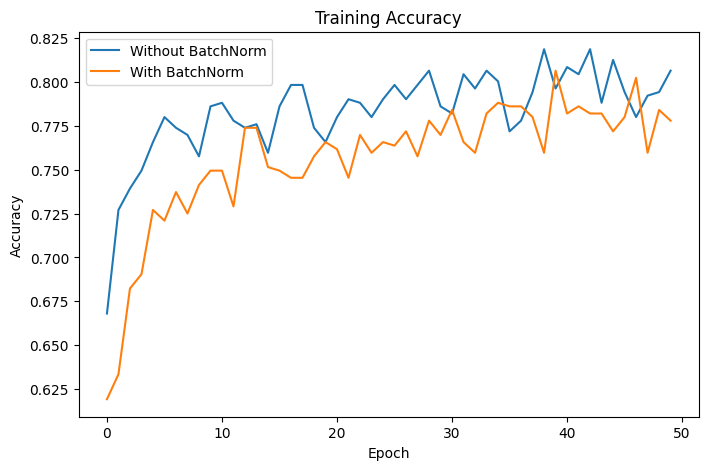

In [18]:
plt.figure(figsize=(8,5))

plt.plot(history_without_bn.history['accuracy'], label='Without BatchNorm')
plt.plot(history_with_bn.history['accuracy'], label='With BatchNorm')

plt.title("Training Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.show()

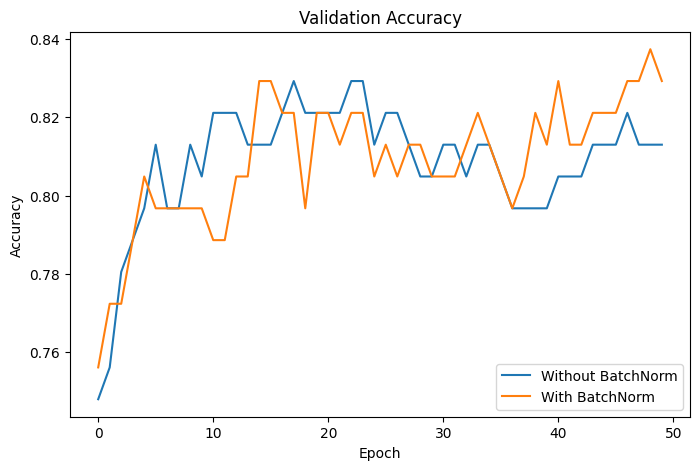

In [19]:
plt.figure(figsize=(8,5))

plt.plot(history_without_bn.history['val_accuracy'], label='Without BatchNorm')
plt.plot(history_with_bn.history['val_accuracy'], label='With BatchNorm')

plt.title("Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.show()

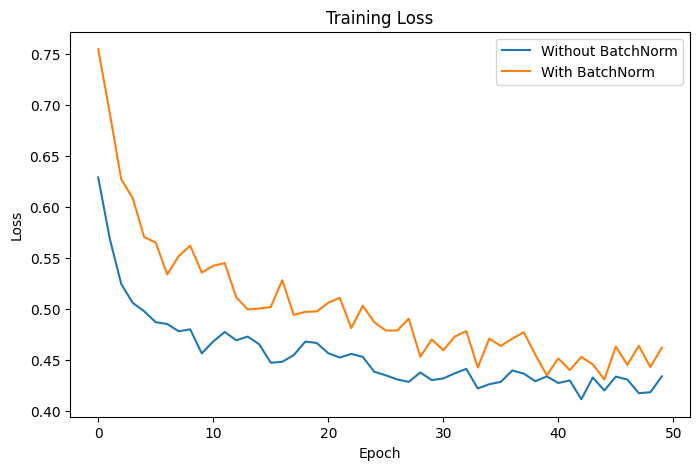

In [20]:
plt.figure(figsize=(8,5))

plt.plot(history_without_bn.history['loss'], label='Without BatchNorm')
plt.plot(history_with_bn.history['loss'], label='With BatchNorm')

plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()